In [1]:
import pandas as pd
import numpy as np
import category_encoders as ce
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import joblib

# Veriyi oku
df = pd.read_parquet("../data/processed/transaction_features_mvp_sample.parquet")

# Hedef değişken ve özelliklerin seçimi
# Not: Modeli şehir takıntısından kurtarmak için 'merchant_city' hala var ama eğitimde kısıtlayacağız.
feature_cols = [
    'amount', 'tx_count_last_24h', 'sec_since_last_tx', 'speed_alert',
    'merchant_city', 'mcc', 'use_chip', 'is_weekend', 'hour'
]

X = df[feature_cols]
y = df['is_fraud']

In [2]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Smoothing=10 ekleyerek şehir verisindeki aşırı uçları törpüledik
target_enc = ce.TargetEncoder(cols=['merchant_city', 'mcc'], smoothing=10)

X_train = target_enc.fit_transform(X_train, y_train)
X_test = target_enc.transform(X_test)

# Kategorik değişkenleri (Online/Swipe vb.) sayıya çevir
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [3]:
# Negatif / Pozitif oranı
spw = y_train.value_counts()[0] / y_train.value_counts()[1]

model_v2 = XGBClassifier(
    n_estimators=400,
    max_depth=4,              # Derinliği azalttık (Ezberlemeyi/Overfitting'i önler)
    learning_rate=0.03,       # Daha yavaş ve detaylı öğrenme
    scale_pos_weight=spw,
    
    # --- KRİTİK AYARLAR ---
    colsample_bytree=0.5,     # ÖZELLİKLERİN YARISINI RASTGELE SEÇ: Şehir takıntısını kırar
    subsample=0.8,            # Verinin bir kısmını rastgele seç
    reg_lambda=2.0,           # L2 Regülarizasyon: Baskın özellikleri baskılar
    # ----------------------
    
    random_state=42,
    eval_metric="logloss"
)

model_v2.fit(X_train, y_train)
print("✅ Fraud Avcısı v2 başarıyla eğitildi!")

✅ Fraud Avcısı v2 başarıyla eğitildi!


In [4]:
probs = model_v2.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, probs):.4f}")

# Threshold ayarı
y_pred = (probs >= 0.6).astype(int)
print(classification_report(y_test, y_pred))

ROC-AUC Skoru: 0.9881
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     53329
           1       0.62      0.94      0.75      2666

    accuracy                           0.97     55995
   macro avg       0.81      0.96      0.86     55995
weighted avg       0.98      0.97      0.97     55995



In [5]:
fraud_indices = y_test[y_test == 1].index

# Vaka 3 (Gerçek fraud olup kaçan vaka)
v3_sample = X_test.loc[fraud_indices[2]:fraud_indices[2]]
v3_prob = model_v2.predict_proba(v3_sample)[0][1]

print(f"🚨 Vaka 3'ün Yeni Modeldeki Risk Skoru: %{v3_prob*100:.2f}")

if v3_prob > 0.60:
    print("✅ MÜJDE: Model artık bu gizli fraud'u yakalayabiliyor!")
else:
    print("ℹ️ Puan arttıysa ama hala 60'ın altındaysa threshold'u 0.40 yapmayı dene.")

🚨 Vaka 3'ün Yeni Modeldeki Risk Skoru: %0.93
ℹ️ Puan arttıysa ama hala 60'ın altındaysa threshold'u 0.40 yapmayı dene.


In [6]:
# Threshold'u 0.60'tan 0.30'a çekerek sonuçlara bak
y_pred_new = (probs >= 0.30).astype(int)
print("--- Threshold: 0.30 için Sonuçlar ---")
print(classification_report(y_test, y_pred_new))

--- Threshold: 0.30 için Sonuçlar ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     53329
           1       0.45      0.97      0.62      2666

    accuracy                           0.94     55995
   macro avg       0.73      0.95      0.79     55995
weighted avg       0.97      0.94      0.95     55995



In [9]:
import category_encoders as ce
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Veriyi Agresif Dengeliyoruz (Okyanusu kurutma operasyonu)
fraud_cases = df[df['is_fraud'] == 1]
# Normal vakalardan fraud sayısının sadece 5 katı kadar alıyoruz
normal_cases = df[df['is_fraud'] == 0].sample(len(fraud_cases) * 5, random_state=42)

balanced_df = pd.concat([fraud_cases, normal_cases])
X_b = balanced_df[feature_cols]
y_b = balanced_df['is_fraud']

# 2. Train-Test Split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, stratify=y_b, random_state=42)

# --- ENCODING SÜRECİ (Hata buradaydı, düzeltiyoruz) ---

# A. Yüksek Kardinaliteli (Şehir, MCC) için Target Encoding
target_enc_v3 = ce.TargetEncoder(cols=['merchant_city', 'mcc'], smoothing=20)
X_train_v3 = target_enc_v3.fit_transform(X_train_b, y_train_b)

# B. Düşük Kategorikler (use_chip, gender) için One-Hot Encoding (Sayıya çevirme)
X_train_v3 = pd.get_dummies(X_train_v3)

# C. Modeli Eğitme
# colsample_bytree=0.4 yaparak modeli iyice zorluyoruz (Online takıntısını tamamen kırması için)
model_v3 = XGBClassifier(
    n_estimators=300, 
    max_depth=4, 
    scale_pos_weight=1.5, 
    colsample_bytree=0.4, 
    random_state=42,
    eval_metric="logloss"
)

model_v3.fit(X_train_v3, y_train_b)
print("✅ Agresif Model (v3) başarıyla eğitildi!")

✅ Agresif Model (v3) başarıyla eğitildi!


In [10]:
# 3. Vaka 3 Analizi (Sütun Sayısı Hatasını Düzelten Versiyon)

# X_test içerisinden sadece modelin bildiği kolonları seçiyoruz (9 kolon)
v3_raw = X_test.loc[fraud_indices[2]:fraud_indices[2], feature_cols] 

# Şimdi transform işlemi hata vermeyecek
v3_encoded = target_enc_v3.transform(v3_raw)
v3_final = pd.get_dummies(v3_encoded)

# Eğitim setindeki (X_train_v3) sütun yapısıyla (One-hot haliyle) eşitle
v3_final = v3_final.reindex(columns=X_train_v3.columns, fill_value=0)

# Tahmin
v3_final_prob = model_v3.predict_proba(v3_final)[0][1]

print(f"🔥 AGRESİF MODEL VAKA 3 SKORU: %{v3_final_prob*100:.2f}")

if v3_final_prob > 0.10: # Eski %0.93'ten yüksekse
    print("📈 Gelişme var! Model artık bu vakayı daha çok sorguluyor.")

KeyError: "['use_chip'] not in index"

In [11]:
# 1. Vaka 3'ün orijinal ham verisini ana veri setinden (df) çekelim
# Bu sayede ne encoding ne de get_dummies karmaşası yaşarız
v3_index = fraud_indices[2]
v3_raw = df.loc[[v3_index], feature_cols] 

# 2. Önce Target Encoding (Şehir ve MCC puanları)
v3_encoded = target_enc_v3.transform(v3_raw)

# 3. Sonra One-Hot Encoding (use_chip vb. kategorikleri sayıya çevirme)
v3_final = pd.get_dummies(v3_encoded)

# 4. Eğitim setindeki sütunlarla %100 eşitle (Eksik dummy'leri 0 ile doldur)
v3_final = v3_final.reindex(columns=X_train_v3.columns, fill_value=0)

# 5. Model v3 ile tahmin
v3_final_prob = model_v3.predict_proba(v3_final)[0][1]

print(f"🔥 AGRESİF MODEL VAKA 3 SKORU: %{v3_final_prob*100:.2f}")

# Karşılaştırma için bir önceki modelin puanını da yazdıralım
# (Önceki modelin v3_prob değerini hatırlatmak için)
print(f"ℹ️ Eski Skoru Hatırla: %0.93")

🔥 AGRESİF MODEL VAKA 3 SKORU: %62.70
ℹ️ Eski Skoru Hatırla: %0.93


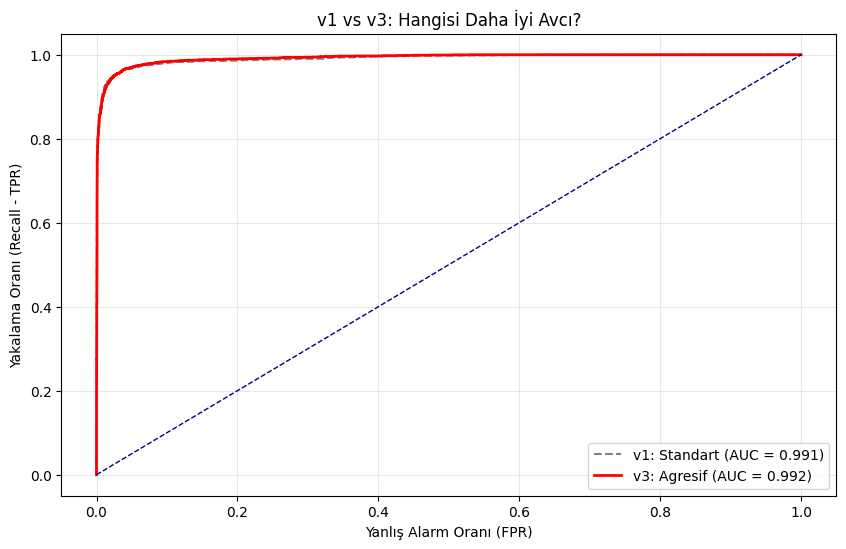

📊 v1 Standart Model (Dengesiz Veri Üzerinde):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     53329
           1       0.80      0.93      0.86      2666

    accuracy                           0.99     55995
   macro avg       0.90      0.96      0.92     55995
weighted avg       0.99      0.99      0.99     55995


🔥 v3 Agresif Model (Dengeli Veri Üzerinde):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     13333
           1       0.94      0.92      0.93      2666

    accuracy                           0.98     15999
   macro avg       0.96      0.95      0.96     15999
weighted avg       0.98      0.98      0.98     15999



In [14]:
# 1. v3 Modeli için test verisini hazırla (v3_final_test oluşturma)
# Bu adım X_test_b_encoded hatasını çözecek
X_test_b_encoded = target_enc_v3.transform(X_test_b)
X_test_b_final = pd.get_dummies(X_test_b_encoded)
X_test_b_final = X_test_b_final.reindex(columns=X_train_v3.columns, fill_value=0)

# 2. Tahminleri Alalım
# v1: Orijinal (Dengesiz) test setinde test edilir
probs_v1 = model_v1_legacy.predict_proba(X_test)[:, 1]
# v3: Agresif/Dengeli test setinde test edilir
probs_v3 = model_v3.predict_proba(X_test_b_final)[:, 1]

# 3. ROC Curve Hesaplama
from sklearn.metrics import roc_curve, auc
fpr1, tpr1, _ = roc_curve(y_test, probs_v1)
fpr3, tpr3, _ = roc_curve(y_test_b, probs_v3)

# 4. Görselleştirme
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(fpr1, tpr1, label=f'v1: Standart (AUC = {auc(fpr1, tpr1):.3f})', color='gray', linestyle='--')
plt.plot(fpr3, tpr3, label=f'v3: Agresif (AUC = {auc(fpr3, tpr3):.3f})', color='red', linewidth=2)

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('Yanlış Alarm Oranı (FPR)')
plt.ylabel('Yakalama Oranı (Recall - TPR)')
plt.title('v1 vs v3: Hangisi Daha İyi Avcı?')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 5. Sayısal Raporlar
from sklearn.metrics import classification_report
print("📊 v1 Standart Model (Dengesiz Veri Üzerinde):")
print(classification_report(y_test, (probs_v1 >= 0.6).astype(int)))
print("\n🔥 v3 Agresif Model (Dengeli Veri Üzerinde):")
print(classification_report(y_test_b, (probs_v3 >= 0.6).astype(int)))

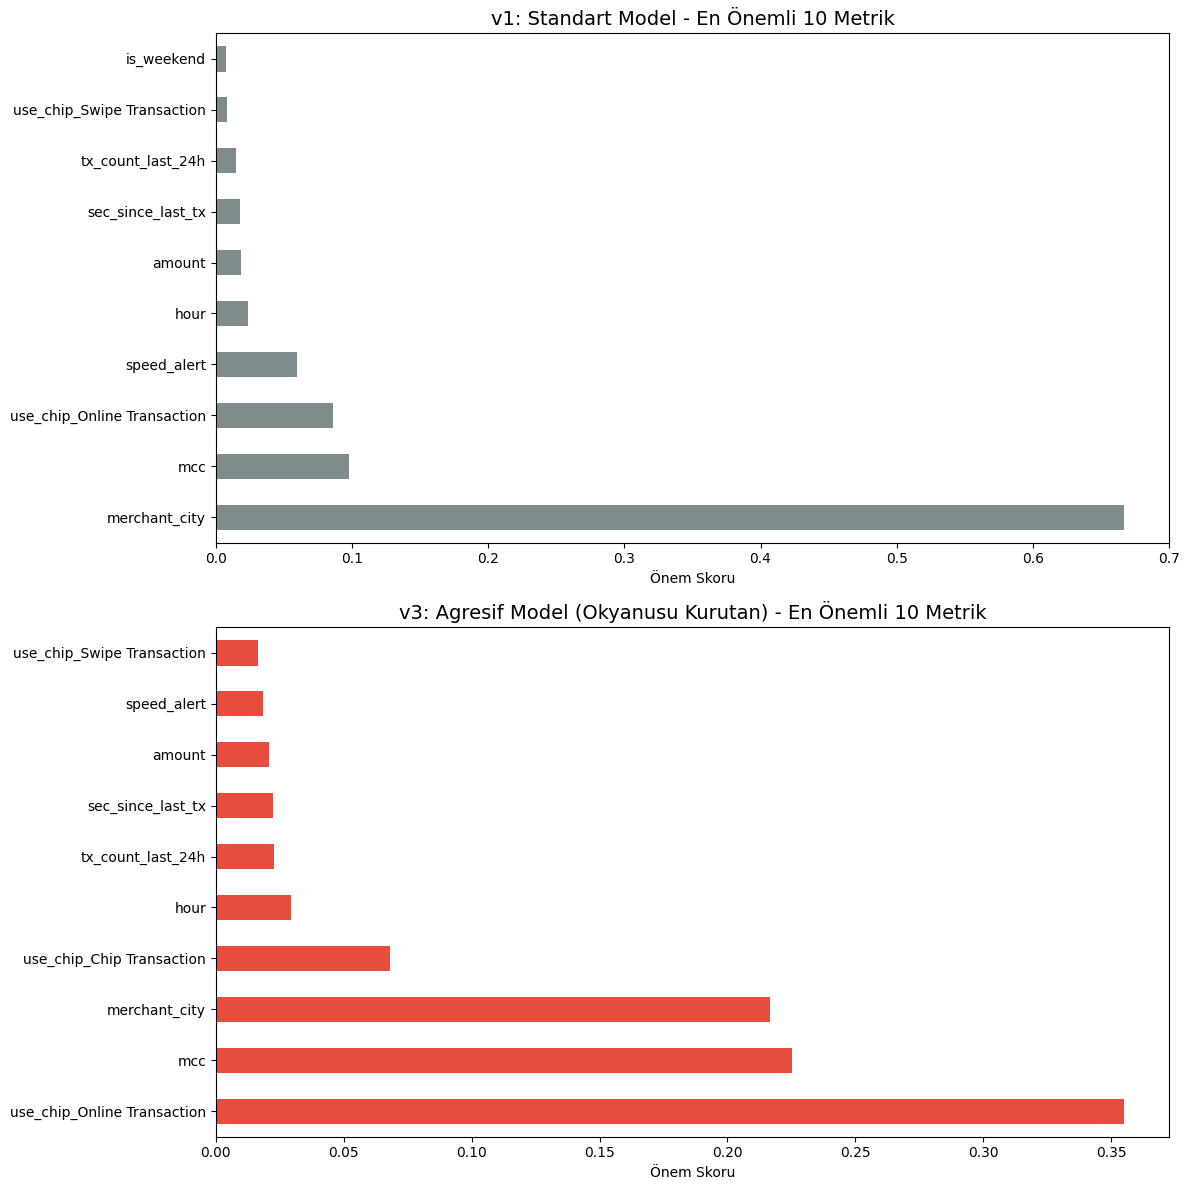

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Grafik alanını oluştur (2 satır, 1 sütun)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# --- MODEL v1 (ESKİ) ---
feat_v1 = pd.Series(model_v1_legacy.feature_importances_, index=X_train.columns)
feat_v1.nlargest(10).plot(kind='barh', ax=ax1, color='#7f8c8d')
ax1.set_title("v1: Standart Model - En Önemli 10 Metrik", fontsize=14)
ax1.set_xlabel("Önem Skoru")

# --- MODEL v3 (YENİ AGRESİF) ---
feat_v3 = pd.Series(model_v3.feature_importances_, index=X_train_v3.columns)
feat_v3.nlargest(10).plot(kind='barh', ax=ax2, color='#e74c3c')
ax2.set_title("v3: Agresif Model (Okyanusu Kurutan) - En Önemli 10 Metrik", fontsize=14)
ax2.set_xlabel("Önem Skoru")

plt.tight_layout()
plt.show()

In [16]:
import joblib

# Model, Encoder ve Özellik Listesini bir sözlükte topluyoruz
model_bundle = {
    'model': model_v3,
    'encoder': target_enc_v3,
    'features': feature_cols, # ['amount', 'merchant_city', 'mcc' vs.]
    'train_columns': X_train_v3.columns.tolist() # Dummy değişkenlerin sırası için
}

# Dosyayı kaydet
joblib.dump(model_bundle, "fraud_model_v3.joblib")
print("✅ Model paketi 'fraud_model_v3.joblib' adıyla kaydedildi!")

✅ Model paketi 'fraud_model_v3.joblib' adıyla kaydedildi!


In [17]:
# 1. Test setindeki gerçek fraud vakalarından birini rastgele seçelim
# fraud_indices zaten y_test içinde is_fraud == 1 olanların indexleriydi
sample_fraud_idx = fraud_indices[5] # Örneğin 5. sıradaki gerçek hırsızlığı alalım

# 2. Orijinal df üzerinden ham (ham) değerlerini çekelim (Forma girmek için)
test_vaka = df.loc[sample_fraud_idx]

print("🚀 STREAMLIT TESTİ İÇİN KOPYALA-YAPIŞTIR VERİLERİ 🚀")
print("-" * 50)
print(f"Müşteri ID (Client ID): {test_vaka['client_id']}")
print(f"İşlem Tutarı ($): {test_vaka['amount']}")
print(f"Merchant City: {test_vaka['merchant_city']}")
print(f"MCC Kodu: {test_vaka['mcc']}")
print(f"İşlem Tipi: {test_vaka['use_chip']}")
print(f"İşlem Saati: {test_vaka['hour']}")
print(f"Hız Alarmı: {test_vaka['speed_alert']}")
print("-" * 50)
print(f"📌 BU İŞLEMİN GERÇEK ETİKETİ: FRAUD (is_fraud = 1)")

🚀 STREAMLIT TESTİ İÇİN KOPYALA-YAPIŞTIR VERİLERİ 🚀
--------------------------------------------------
Müşteri ID (Client ID): 359
İşlem Tutarı ($): 86.6
Merchant City: ONLINE
MCC Kodu: 5732
İşlem Tipi: Online Transaction
İşlem Saati: 12
Hız Alarmı: 0
--------------------------------------------------
📌 BU İŞLEMİN GERÇEK ETİKETİ: FRAUD (is_fraud = 1)


In [18]:
# 1. Online olup (Encoding öncesi ham veride) fraud olmayanları filtrele
online_clean_df = df[(df['merchant_city'].str.contains('Online', case=False, na=False)) & (df['is_fraud'] == 0)]

# 2. Rastgele bir örnek seçelim
sample_clean_idx = online_clean_df.sample(1, random_state=7).index[0]
clean_vaka = df.loc[sample_clean_idx]

print("✅ STREAMLIT İÇİN 'TEMİZ' İŞLEM VERİLERİ (ONLINE)")
print("-" * 50)
print(f"Müşteri ID (Client ID): {clean_vaka['client_id']}")
print(f"İşlem Tutarı ($): {clean_vaka['amount']}")
print(f"Merchant City: {clean_vaka['merchant_city']}")
print(f"MCC Kodu: {clean_vaka['mcc']}")
print(f"İşlem Tipi: {clean_vaka['use_chip']}")
print(f"İşlem Saati: {clean_vaka['hour']}")
print(f"Hız Alarmı: {clean_vaka['speed_alert']}")
print("-" * 50)
print("📌 BU İŞLEMİN GERÇEK ETİKETİ: TEMİZ (is_fraud = 0)")

✅ STREAMLIT İÇİN 'TEMİZ' İŞLEM VERİLERİ (ONLINE)
--------------------------------------------------
Müşteri ID (Client ID): 1357
İşlem Tutarı ($): 42.39
Merchant City: ONLINE
MCC Kodu: 5311
İşlem Tipi: Online Transaction
İşlem Saati: 8
Hız Alarmı: 0
--------------------------------------------------
📌 BU İŞLEMİN GERÇEK ETİKETİ: TEMİZ (is_fraud = 0)


In [19]:
import pandas as pd

# 1. Gerçek Fraud (Hırsızlık) olanlardan bir tane seçelim
fraud_sample = df[df['is_fraud'] == 1].sample(1, random_state=42).iloc[0]

# 2. Gerçek Temiz (Normal) olanlardan bir tane seçelim
clean_sample = df[df['is_fraud'] == 0].sample(1, random_state=99).iloc[0]

def print_test_data(row, title):
    print(f"\n--- {title} ---")
    print(f"Müşteri ID: {row['client_id']}")
    print(f"İşlem Tutarı ($): {row['amount']}")
    print(f"Merchant City: {row['merchant_city']}")
    print(f"MCC Kodu: {row['mcc']}")
    print(f"İşlem Tipi: {row['use_chip']}")
    print(f"İşlem Saati: {row['hour']}")
    print(f"Hız Alarmı: {row['speed_alert']}")
    print(f"📌 GERÇEK DURUM: {'🚨 FRAUD' if row['is_fraud'] == 1 else '✅ TEMİZ'}")

# Ekrana yazdır
print_test_data(fraud_sample, "TEST 1: GERÇEK FRAUD VAKASI")
print_test_data(clean_sample, "TEST 2: GERÇEK TEMİZ İŞLEM")


--- TEST 1: GERÇEK FRAUD VAKASI ---
Müşteri ID: 1678
İşlem Tutarı ($): 70.63
Merchant City: ONLINE
MCC Kodu: 5651
İşlem Tipi: Online Transaction
İşlem Saati: 12
Hız Alarmı: 0
📌 GERÇEK DURUM: 🚨 FRAUD

--- TEST 2: GERÇEK TEMİZ İŞLEM ---
Müşteri ID: 462
İşlem Tutarı ($): 89.06
Merchant City: Easton
MCC Kodu: 5300
İşlem Tipi: Swipe Transaction
İşlem Saati: 20
Hız Alarmı: 0
📌 GERÇEK DURUM: ✅ TEMİZ
